# **Olist E-Commerce Analytics — Customer Experience & Marketplace Performance**

## **1. Project Introduction**

This project analyzes approximately 100,000 orders from the Olist Brazilian
e-commerce marketplace between September 2016 and October 2018.

The objective is to understand marketplace performance, customer satisfaction,
delivery performance, seller and geographic patterns, product category
performance, and payment behavior.

The analysis uses evidence from the Olist transactional dataset to identify
the factors most strongly associated with customer satisfaction and
dissatisfaction and translate those findings into actionable business
recommendations.

### Analytical Focus

*  Marketplace Performance Over Time
*  Delivery Performance & Customer Satisfaction
* Seller & Geographic Patterns
* Product Category Performance
* Payment Behavior
* Root Cause Analysis of Low Review Scores

## **2. Business Problem**

Olist has approximately two years of marketplace data covering orders,
products, payments, sellers, customers, delivery information, and customer
reviews.

The key business challenge is to understand what is actually driving
marketplace performance and customer satisfaction.

## **3. Objectives**

The analysis aims to answer six core business questions:

* **Marketplace Performance Over Time :**
How have order volume, revenue, and review scores changed over time?
Do these metrics tell the same story?

* **Delivery Performance & Customer Satisfaction :**
How does actual delivery timing relative to the estimated delivery date
relate to customer review scores?

* **Seller & Geographic Patterns :**
How do seller and customer locations relate to delivery performance,
freight cost, and customer satisfaction?

* **Product Category Performance :**
Which product categories generate the most orders and revenue?
Which categories have unusually high or low customer satisfaction?

* **Payment Behavior :**
How do payment methods and installment choices relate to order value
and customer experience?

* **Root Cause Analysis :**
What factors are most strongly associated with low customer review scores?

### **Important Analytical Principle**

This is observational data. Therefore, the analysis will identify
associations and patterns rather than claim definitive causation.

## **4. Import Libraries**

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


## **5. Load Dataset**

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Google Drive path
path = "/content/drive/MyDrive/Brazilian_E-Commerce_Datasets/"

In [11]:
# Load all datasets

orders = pd.read_csv(path + "olist_orders_dataset.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
order_payments = pd.read_csv(path + "olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(path + "olist_order_reviews_dataset.csv")
customers = pd.read_csv(path + "olist_customers_dataset.csv")
products = pd.read_csv(path + "olist_products_dataset.csv")
sellers = pd.read_csv(path + "olist_sellers_dataset.csv")
geolocation = pd.read_csv(path + "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(path + "product_category_name_translation.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [12]:
# Store all the datasets in a dictionary
datasets = {
    "Orders": orders,
    "Order Items": order_items,
    "Order Payments": order_payments,
    "Order Reviews": order_reviews,
    "Customers": customers,
    "Products": products,
    "Sellers": sellers,
    "Geolocation": geolocation,
    "Category Translation": category_translation
}

# Print all datasets along with their shape
for name, df in datasets.items():
    print(f"{name:25} {df.shape}")

Orders                    (99441, 8)
Order Items               (112650, 7)
Order Payments            (103886, 5)
Order Reviews             (99224, 7)
Customers                 (99441, 5)
Products                  (32951, 9)
Sellers                   (3095, 4)
Geolocation               (1000163, 5)
Category Translation      (71, 2)


## **6. Data Understanding**

In [13]:
# Loop through each dataset in the dictionary
for name, df in datasets.items():

    # Print the dataset name in uppercase
    print("\n\n\n\n" + "=" * 20)
    print(name.upper())
    print("=" * 20)

    # Print the dataset shape and column names
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())

    # Print the first 3 rows of each dataset
    print("\nFirst 3 rows:")
    display(df.head(3))





ORDERS
Shape: (99441, 8)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00






ORDER ITEMS
Shape: (112650, 7)

Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

First 3 rows:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87






ORDER PAYMENTS
Shape: (103886, 5)

Columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

First 3 rows:


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ






GEOLOCATION
Shape: (1000163, 5)

Columns:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

First 3 rows:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP






CATEGORY TRANSLATION
Shape: (71, 2)

Columns:
['product_category_name', 'product_category_name_english']

First 3 rows:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


In [14]:
# Display information about the Orders dataset
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [15]:
# Create an empty list to store missing value information
missing_summary = []

# Loop through each dataset
for name, df in datasets.items():

    # Calculate the number of missing values in each column
    missing = df.isnull().sum()

    # Loop through each column and its missing value count
    for column, count in missing.items():

        # Store information only for columns that contain missing values
        if count > 0:
            missing_summary.append({
                "Dataset": name,
                "Column": column,
                "Missing_Count": count,
                "Missing_Percentage": round(
                    count / len(df) * 100, 2
                )
            })

# Convert the missing value information into a DataFrame
missing_df = pd.DataFrame(missing_summary)

# Sort the results by missing percentage in descending order
missing_df.sort_values(
    "Missing_Percentage",
    ascending=False
)

,Dataset,Column,Missing_Count,Missing_Percentage
3,Order Reviews,review_comment_title,87656,88.34
4,Order Reviews,review_comment_message,58247,58.70
2,Orders,order_delivered_customer_date,2965,2.98
6,Products,product_name_lenght,610,1.85
5,Products,product_category_name,610,1.85
7,Products,product_description_lenght,610,1.85
8,Products,product_photos_qty,610,1.85
1,Orders,order_delivered_carrier_date,1783,1.79
0,Orders,order_approved_at,160,0.16
9,Products,product_weight_g,2,0.01


## **7. Data Cleaning**

In [16]:
# Store all date columns that need to be converted into datetime format
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

# Loop through each date column
for col in date_columns:

    # Convert the column values into datetime format
    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce"
    )

# Display the data types of all converted date columns
orders[date_columns].dtypes

,0
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [17]:
# Count the number of orders for each order status
orders["order_status"].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


## **8. Create Analytical Dataset**

In [18]:
# Group the order items dataset by order ID
order_items_agg = (
    order_items
    .groupby("order_id")
    .agg(
        # Count the total number of items in each order
        order_item_count=("order_item_id", "count"),

        # Calculate the total product price for each order
        order_value=("price", "sum"),

        # Calculate the total freight value for each order
        freight_value=("freight_value", "sum"),

        # Count the number of unique products in each order
        unique_products=("product_id", "nunique"),

        # Count the number of unique sellers in each order
        unique_sellers=("seller_id", "nunique")
    )
    .reset_index()
)

# Display the first 5 rows
display(order_items_agg.head())

,order_id,order_item_count,order_value,freight_value,unique_products,unique_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,1,1
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,1,1
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,1,1
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,1,1


In [19]:
# Merge order items with the products dataset
order_category = (
    order_items
    .merge(
        products[
            [
                "product_id",
                "product_category_name"
            ]
        ],
        on="product_id",
        how="left"
    )
)

# Merge with the category translation dataset
order_category = (
    order_category
    .merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
)

# Keep only order ID and product category
order_category = order_category[
    [
        "order_id",
        "product_category_name_english"
    ]
]

# Keep one representative category for each order
order_category = (
    order_category
    .groupby("order_id")
    .first()
    .reset_index()
)

# Display the first 5 rows
display(order_category.head())

,order_id,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,pet_shop
2,000229ec398224ef6ca0657da4fc703e,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools


In [20]:
# Group the order payments dataset by order ID
payment_agg = (
    order_payments
    .groupby("order_id")
    .agg(
        # Calculate the total payment value for each order
        payment_value=("payment_value", "sum"),

        # Get the maximum number of installments
        payment_installments=("payment_installments", "max"),

        # Count the number of different payment types
        payment_types=("payment_type", "nunique")
    )
    .reset_index()
)

# Display the first 5 rows
display(payment_agg.head())

,order_id,payment_value,payment_installments,payment_types
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1


In [21]:
# Sort payment records by order ID and payment sequence
primary_payment = (
    order_payments
    .sort_values(
        [
            "order_id",
            "payment_sequential"
        ]
    )

    # Group payment records by order ID
    .groupby("order_id")

    # Select the first payment record
    .first()

    # Convert the result back into a DataFrame
    .reset_index()[
        [
            "order_id",
            "payment_type"
        ]
    ]
)

# Display the first 5 rows
display(primary_payment.head())

,order_id,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,credit_card
1,00018f77f2f0320c557190d7a144bdd3,credit_card
2,000229ec398224ef6ca0657da4fc703e,credit_card
3,00024acbcdf0a6daa1e931b038114c75,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,credit_card


In [22]:
# Group the order reviews dataset by order ID
review_agg = (
    order_reviews
    .groupby("order_id")
    .agg(
        # Calculate the average review score for each order
        review_score=("review_score", "mean")
    )
    .reset_index()
)

# Display the first 5 rows
display(review_agg.head())

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [23]:
# Start with the Orders dataset as the main table
analysis_df = (
    orders

    # Add customer information using customer ID
    .merge(
        customers,
        on="customer_id",
        how="left"
    )

    # Add aggregated order item information using order ID
    .merge(
        order_items_agg,
        on="order_id",
        how="left"
    )

    # Add aggregated payment information using order ID
    .merge(
        payment_agg,
        on="order_id",
        how="left"
    )

    # Add the primary payment type using order ID
    .merge(
        primary_payment,
        on="order_id",
        how="left"
    )

    # Add review information using order ID
    .merge(
        review_agg,
        on="order_id",
        how="left"
    )

    # Add product category using order ID
    .merge(
        order_category,
        on="order_id",
        how="left"
    )
)

# Print the shape of the final analytical dataset
print("Analytical dataset shape:", analysis_df.shape)

# Display the first 5 rows
display(analysis_df.head())

Analytical dataset shape: (99441, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_count,order_value,freight_value,unique_products,unique_sellers,payment_value,payment_installments,payment_types,payment_type,review_score,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,29.99,8.72,1.0,1.0,38.71,1.0,2.0,credit_card,4.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,118.70,22.76,1.0,1.0,141.46,1.0,1.0,boleto,4.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,159.90,19.22,1.0,1.0,179.12,3.0,1.0,credit_card,5.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,45.00,27.20,1.0,1.0,72.20,1.0,1.0,credit_card,5.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,19.90,8.72,1.0,1.0,28.62,1.0,1.0,credit_card,5.0,stationery


In [24]:
# Print the total number of rows
print("Total rows:", len(analysis_df))

# Print the number of unique orders
print("Unique orders:", analysis_df["order_id"].nunique())

# Check whether there is exactly one row per order
print(
    "One row per order:",
    len(analysis_df) == analysis_df["order_id"].nunique()
)

Total rows: 99441
Unique orders: 99441
One row per order: True


## **9. KPI Overview**

In [25]:
# Calculate the total number of unique orders
total_orders = analysis_df["order_id"].nunique()

# Calculate the total revenue based on the total payment value
total_revenue = analysis_df["payment_value"].sum()

# Calculate the average order value
average_order_value = analysis_df["payment_value"].mean()

# Total delivered orders (unique)
total_delivered_orders = analysis_df[analysis_df["order_status"] == "delivered"]["order_id"].nunique()

# Calculate the average customer review score
average_review_score = analysis_df["review_score"].mean()

# Display the key marketplace KPIs
print(f"Total Orders:           {total_orders:,.0f}")
print(f"Total Revenue:          R$ {total_revenue:,.2f}")
print(f"Average Order Value:    R$ {average_order_value:,.2f}")
print(f"Total Delivered Orders: {total_delivered_orders}")
print(f"Average Review Score:   {average_review_score:.2f}/5")

Total Orders:           99,441
Total Revenue:          R$ 16,008,872.12
Average Order Value:    R$ 160.99
Total Delivered Orders: 96478
Average Review Score:   4.09/5


## **10. Question 1 — Marketplace Performance Over Time**

In [26]:
# Create a proper monthly time dimension from the order purchase timestamp.
analysis_df["purchase_date"] = analysis_df["order_purchase_timestamp"].dt.date
analysis_df["purchase_month"] = analysis_df["order_purchase_timestamp"].dt.to_period("M")
analysis_df["purchase_year"] = analysis_df["order_purchase_timestamp"].dt.year

print(
    "Purchase period:",
    analysis_df["purchase_month"].min(),
    "to",
    analysis_df["purchase_month"].max()
)

Purchase period: 2016-09 to 2018-10


In [27]:
# Aggregate marketplace performance by purchase month.
monthly_performance = (
    analysis_df
    .groupby("purchase_month")
    .agg(
        order_volume=("order_id", "nunique"),
        revenue=("payment_value", "sum"),
        average_review_score=("review_score", "mean")
    )
    .reset_index()
)

# Convert Period to timestamp for plotting.
monthly_performance["purchase_month"] = monthly_performance["purchase_month"].dt.to_timestamp()

display(monthly_performance)

,purchase_month,order_volume,revenue,average_review_score
0,2016-09-01,4,252.24,1.000000
1,2016-10-01,324,59090.48,3.561129
2,2016-12-01,1,19.62,5.000000
3,2017-01-01,800,138488.04,4.062658
4,2017-02-01,1780,291908.01,4.015837
5,2017-03-01,2682,449863.60,4.074596
6,2017-04-01,2404,417788.03,4.046083
7,2017-05-01,3700,592918.82,4.142117
8,2017-06-01,3245,511276.38,4.147763
9,2017-07-01,4026,592382.92,4.175397


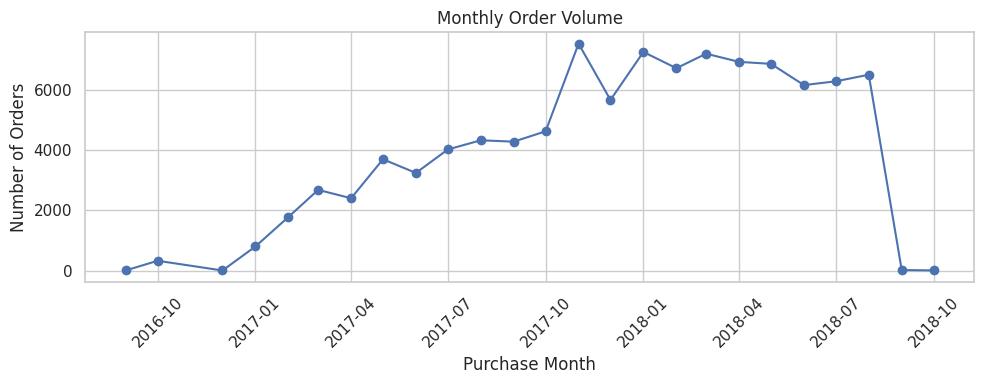

In [28]:
plt.figure(figsize=(10, 4))

plt.plot(
    monthly_performance["purchase_month"],
    monthly_performance["order_volume"],
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

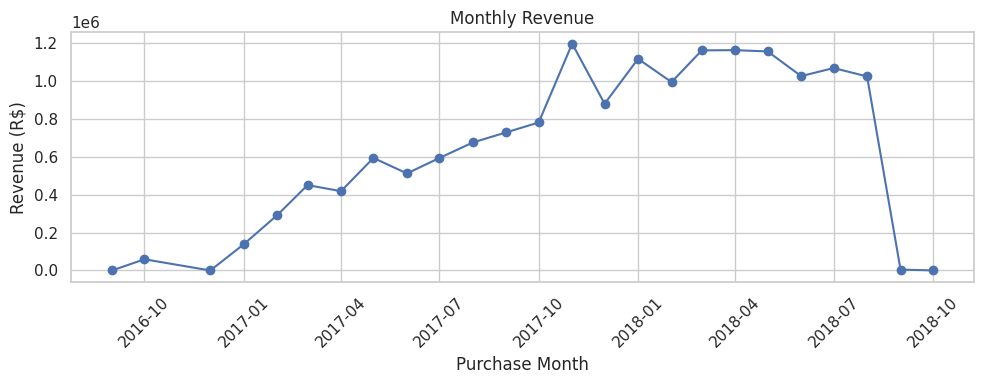

In [29]:
plt.figure(figsize=(10, 4))

plt.plot(
    monthly_performance["purchase_month"],
    monthly_performance["revenue"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Purchase Month")
plt.ylabel("Revenue (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

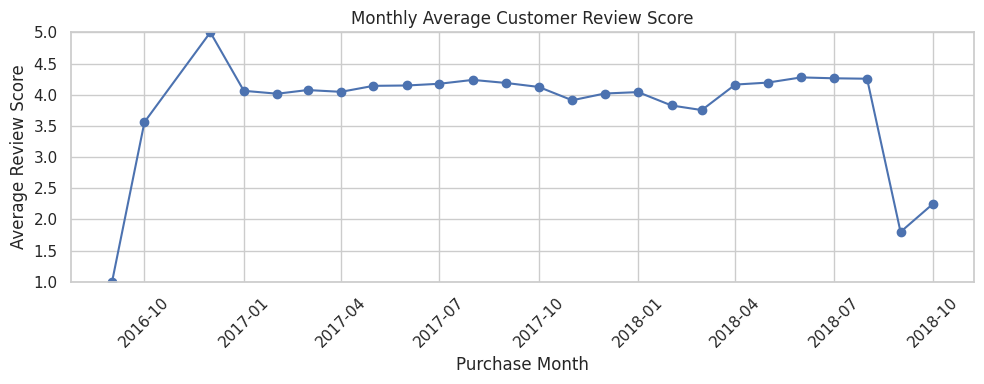

In [30]:
plt.figure(figsize=(10, 4))

plt.plot(
    monthly_performance["purchase_month"],
    monthly_performance["average_review_score"],
    marker="o"
)

plt.title("Monthly Average Customer Review Score")
plt.xlabel("Purchase Month")
plt.ylabel("Average Review Score")
plt.ylim(1, 5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
# Normalize the three marketplace metrics to make their trends comparable.
monthly_index = monthly_performance.copy()

monthly_index["order_volume_index"] = (
    monthly_index["order_volume"] / monthly_index["order_volume"].max()
)

monthly_index["revenue_index"] = (
    monthly_index["revenue"] / monthly_index["revenue"].max()
)

monthly_index["review_score_index"] = (
    monthly_index["average_review_score"]
    / monthly_index["average_review_score"].max()
)

display(
    monthly_index[
        [
            "purchase_month",
            "order_volume_index",
            "revenue_index",
            "review_score_index"
        ]
    ]
)

,purchase_month,order_volume_index,revenue_index,review_score_index
0,2016-09-01,0.000530,0.000211,0.200000
1,2016-10-01,0.042948,0.049453,0.712226
2,2016-12-01,0.000133,0.000016,1.000000
3,2017-01-01,0.106045,0.115901,0.812532
4,2017-02-01,0.235949,0.244298,0.803167
5,2017-03-01,0.355514,0.376492,0.814919
6,2017-04-01,0.318664,0.349648,0.809217
7,2017-05-01,0.490456,0.496215,0.828423
8,2017-06-01,0.430143,0.427888,0.829553
9,2017-07-01,0.533669,0.495767,0.835079


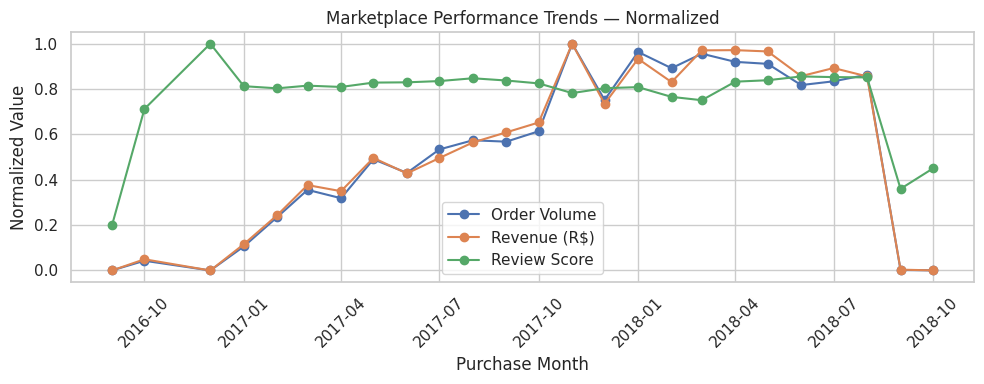

In [32]:
plt.figure(figsize=(10, 4))

plt.plot(
    monthly_index["purchase_month"],
    monthly_index["order_volume_index"],
    marker="o",
    label="Order Volume"
)

plt.plot(
    monthly_index["purchase_month"],
    monthly_index["revenue_index"],
    marker="o",
    label="Revenue (R$)"
)

plt.plot(
    monthly_index["purchase_month"],
    monthly_index["review_score_index"],
    marker="o",
    label="Review Score"
)

plt.title("Marketplace Performance Trends — Normalized")
plt.xlabel("Purchase Month")
plt.ylabel("Normalized Value")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# Compare the first and last observed months.
first_month = monthly_performance.iloc[0]
last_month = monthly_performance.iloc[-1]

order_growth = (
    (last_month["order_volume"] / first_month["order_volume"]) - 1
) * 100

revenue_growth = (
    (last_month["revenue"] / first_month["revenue"]) - 1
) * 100

review_growth = (
    (last_month["average_review_score"] / first_month["average_review_score"]) - 1
) * 100

print(f"Order Volume Growth: {order_growth:.2f}%")
print(f"Revenue Growth: {revenue_growth:.2f}%")
print(f"Review Score Change: {review_growth:.2f}%")

Order Volume Growth: 0.00%
Revenue Growth: 133.77%
Review Score Change: 125.00%


## **11. Question 2 — Delivery Performance & Customer Satisfaction**

In [34]:
# Calculate the delivery delay in days
analysis_df["delivery_delay_days"] = (

    # Subtract the estimated delivery date from the actual delivery date
    analysis_df["order_delivered_customer_date"]

    - analysis_df["order_estimated_delivery_date"]

# Convert the time difference from seconds into days
).dt.total_seconds() / (24 * 60 * 60)

In [35]:
# Create an on-time delivery indicator
analysis_df["on_time_delivery"] = np.where(

    # Check whether the order was delivered on or before the estimated date
    analysis_df["delivery_delay_days"] <= 0,

    # Assign 1 when the order was delivered on time
    1,

    # Assign 0 when the order was delivered late
    0
)

In [36]:
# Calculate the total delivery time in days
analysis_df["delivery_time_days"] = (

    # Get the actual date when the customer received the order
    analysis_df["order_delivered_customer_date"]

    # Subtract the order purchase date
    - analysis_df["order_purchase_timestamp"]

# Convert the time difference from seconds into days
).dt.total_seconds() / (24 * 60 * 60)

In [37]:
# Extract the year and month from the order purchase timestamp
analysis_df["purchase_month"] = (

    # Convert the purchase timestamp into a monthly period
    analysis_df["order_purchase_timestamp"]

    .dt.to_period("M")

    # Convert the monthly period into a string format
    .astype(str)

)

# Extract the purchase year from the order purchase timestamp
analysis_df["purchase_year"] = (

    analysis_df["order_purchase_timestamp"]

    # Extract only the year
    .dt.year

)

In [38]:
# Create delivery delay groups based on the number of days early or late
analysis_df["delay_group"] = pd.cut(
    analysis_df["delivery_delay_days"],
    bins=[
        -np.inf,
        -1,
        0,
        3,
        7,
        14,
        np.inf
    ],
    labels=[
        "Early",
        "On Time",
        "1-3 Days Late",
        "4-7 Days Late",
        "8-14 Days Late",
        "15+ Days Late"
    ]
)

# Count the number of orders in each delay group
display(
    analysis_df["delay_group"].value_counts()
)

,count
delay_group,
Early,87187
1-3 Days Late,2662
4-7 Days Late,1819
8-14 Days Late,1791
15+ Days Late,1555
On Time,1462


In [39]:
# Calculate the average review score for each delivery delay group
delay_review = (
    analysis_df
    .groupby("delay_group", observed=True)
    .agg(
        # Count the number of unique orders in each delay group
        order_count=("order_id", "nunique"),

        # Calculate the average review score for each delay group
        average_review_score=("review_score", "mean")
    )
    .reset_index()
)

# Display the delay group review score summary
display(delay_review)

,delay_group,order_count,average_review_score
0,Early,87187,4.296428
1,On Time,1462,4.157931
2,1-3 Days Late,2662,3.766882
3,4-7 Days Late,1819,2.317259
4,8-14 Days Late,1791,1.746141
5,15+ Days Late,1555,1.710771


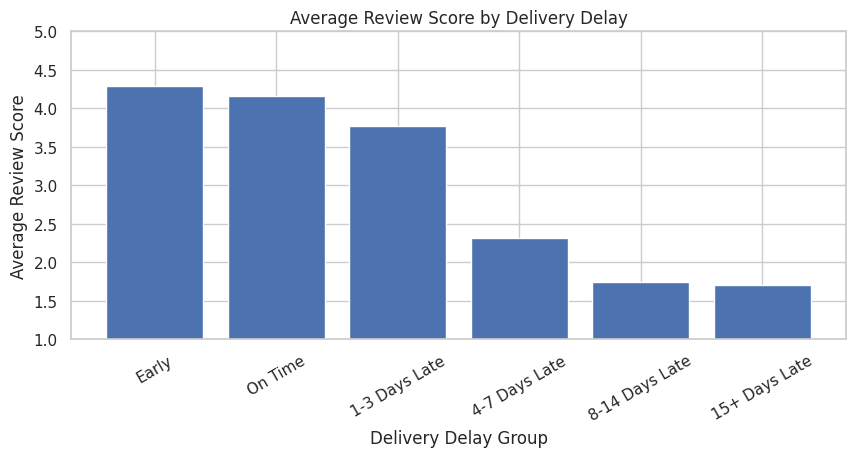

In [40]:
# Create a figure for analyzing the relationship between delivery delay and review score
plt.figure(figsize=(10, 4))

# Create a bar chart showing the average review score for each delay group
plt.bar(
    delay_review["delay_group"].astype(str),
    delay_review["average_review_score"]
)

# Add a title to the chart
plt.title("Average Review Score by Delivery Delay")

# Add a label to the x-axis
plt.xlabel("Delivery Delay Group")

# Add a label to the y-axis
plt.ylabel("Average Review Score")

# Set the review score range from 1 to 5
plt.ylim(1, 5)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=30)

# Display the chart
plt.show()

In [41]:
# Delivery-performance summary.
delivery_summary = pd.DataFrame({
    "Metric": [
        "Average delivery time (days)",
        "Median delivery time (days)",
        "Average delivery delay (days)",
        "On-time delivery rate (%)",
        "Late delivery rate (%)",
        "Average review score"
    ],
    "Value": [
        analysis_df["delivery_time_days"].mean(),
        analysis_df["delivery_time_days"].median(),
        analysis_df["delivery_delay_days"].mean(),
        analysis_df["on_time_delivery"].mean() * 100,
        (1 - analysis_df["on_time_delivery"].mean()) * 100,
        analysis_df["review_score"].mean()
    ]
})

display(delivery_summary.round(2))

,Metric,Value
0,Average delivery time (days),12.56
1,Median delivery time (days),10.22
2,Average delivery delay (days),-11.18
3,On-time delivery rate (%),89.15
4,Late delivery rate (%),10.85
5,Average review score,4.09


In [42]:
# Show the product categories represented in the analytical dataset.
display(
    analysis_df["product_category_name_english"]
    .value_counts(dropna=False)
    .head(20)
    .rename("order_count")
    .to_frame()
)

,order_count
product_category_name_english,
bed_bath_table,9315
health_beauty,8796
sports_leisure,7683
computers_accessories,6661
furniture_decor,6355
housewares,5836
watches_gifts,5601
telephony,4182
auto,3881


## **12. Question 3 — Seller & Geographic Patterns**

Top seller states by revenue:


,order_items,unique_orders,revenue,freight_value,average_freight
seller_state,,,,,
SP,80342,70188,8753396.21,1482487.67,18.45
PR,8671,7673,1261887.21,197013.52,22.72
MG,8827,7930,1011564.74,212595.06,24.08
RJ,4818,4353,843984.22,93829.90,19.47
SC,4075,3667,632426.07,106547.06,26.15
RS,2199,1989,378559.54,57243.09,26.03
BA,643,569,285561.56,19700.68,30.64
DF,899,824,97749.48,18494.06,20.57
PE,448,406,91493.85,12392.46,27.66


Top customer states by order volume:


,orders,revenue,average_order_value,average_review_score,on_time_rate
customer_state,,,,,
SP,41746,5998226.96,143.69,4.17,0.91
RJ,12852,2144379.69,166.85,3.88,0.83
MG,11635,1872257.26,160.92,4.14,0.92
RS,5466,890898.54,162.99,4.13,0.91
PR,5045,811156.38,160.78,4.18,0.93
SC,3637,623086.43,171.32,4.07,0.88
BA,3380,616645.82,182.44,3.86,0.83
DF,2140,355141.08,165.95,4.07,0.90
ES,2033,325967.55,160.34,4.04,0.86


Correlation between freight value and review score: -0.089


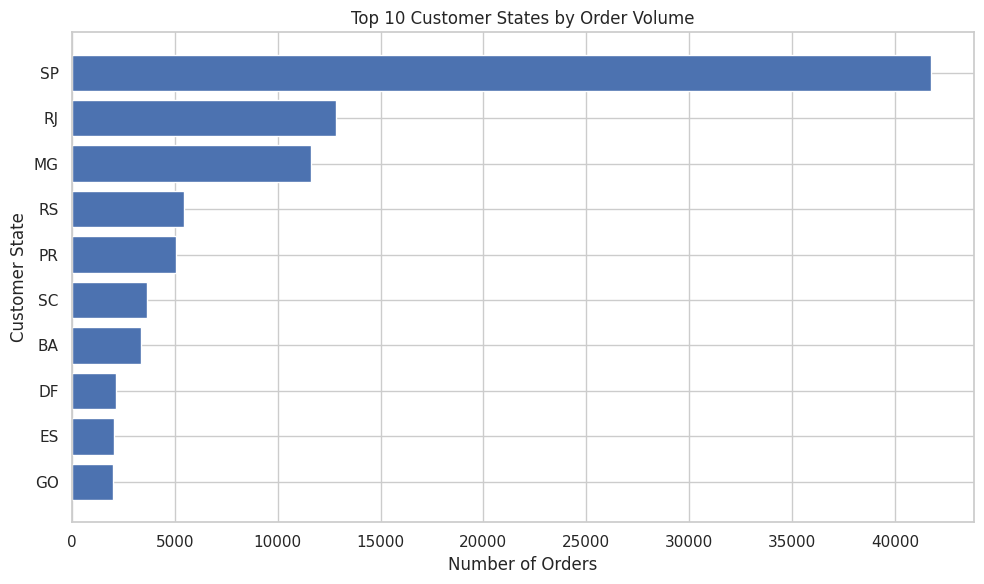

In [43]:
# Build a seller-level and customer-level geographic dataset.
seller_geo = (
    order_items[
        ["order_id", "seller_id", "price", "freight_value"]
    ]
    .merge(
        sellers[["seller_id", "seller_city", "seller_state"]],
        on="seller_id",
        how="left"
    )
    .merge(
        customers[
            ["customer_id", "customer_city", "customer_state"]
        ],
        left_on="order_id",
        right_on="customer_id",
        how="left"
    )
)

# The merge above cannot use order_id -> customer_id directly.
# Rebuild it correctly using the Orders table.
seller_geo = (
    order_items[
        ["order_id", "seller_id", "price", "freight_value"]
    ]
    .merge(
        sellers[["seller_id", "seller_city", "seller_state"]],
        on="seller_id",
        how="left"
    )
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
    .merge(
        customers[
            ["customer_id", "customer_city", "customer_state"]
        ],
        on="customer_id",
        how="left"
    )
)

# Aggregate by seller state.
seller_state_summary = (
    seller_geo
    .groupby("seller_state")
    .agg(
        order_items=("order_id", "count"),
        unique_orders=("order_id", "nunique"),
        revenue=("price", "sum"),
        freight_value=("freight_value", "sum"),
        average_freight=("freight_value", "mean")
    )
    .sort_values("revenue", ascending=False)
)

# Aggregate by customer state.
customer_state_summary = (
    analysis_df
    .groupby("customer_state")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("payment_value", "sum"),
        average_order_value=("payment_value", "mean"),
        average_review_score=("review_score", "mean"),
        on_time_rate=("on_time_delivery", "mean")
    )
    .sort_values("orders", ascending=False)
)

print("Top seller states by revenue:")
display(seller_state_summary.head(10).round(2))

print("Top customer states by order volume:")
display(customer_state_summary.head(10).round(2))

# Relationship between freight cost and customer satisfaction.
freight_review = (
    analysis_df[["freight_value", "review_score"]]
    .dropna()
    .corr()
    .loc["freight_value", "review_score"]
)

print(f"Correlation between freight value and review score: {freight_review:.3f}")

# Visualize the highest-volume customer states.
top_customer_states = customer_state_summary.head(10).sort_values("orders")

plt.figure(figsize=(10, 6))
plt.barh(top_customer_states.index, top_customer_states["orders"])
plt.title("Top 10 Customer States by Order Volume")
plt.xlabel("Number of Orders")
plt.ylabel("Customer State")
plt.tight_layout()
plt.show()

## **13. Question 4 — Product Category Performance**

Top categories by revenue:


,orders,revenue,average_order_value,average_review_score,average_freight
product_category_name_english,,,,,
health_beauty,8796,1439926.41,163.72,4.19,20.74
watches_gifts,5601,1303159.52,232.67,4.07,17.97
bed_bath_table,9315,1241570.64,133.29,3.98,21.98
sports_leisure,7683,1158184.46,150.75,4.17,21.92
computers_accessories,6661,1059496.80,159.06,4.03,22.11
furniture_decor,6355,906602.02,142.66,4.02,27.21
housewares,5836,781450.26,133.90,4.15,25.14
cool_stuff,3604,720981.29,200.05,4.18,23.38
auto,3881,685479.05,176.62,4.09,23.85


Top categories by order volume:


,orders,revenue,average_order_value,average_review_score,average_freight
product_category_name_english,,,,,
bed_bath_table,9315,1241570.64,133.29,3.98,21.98
health_beauty,8796,1439926.41,163.72,4.19,20.74
sports_leisure,7683,1158184.46,150.75,4.17,21.92
computers_accessories,6661,1059496.80,159.06,4.03,22.11
furniture_decor,6355,906602.02,142.66,4.02,27.21
housewares,5836,781450.26,133.90,4.15,25.14
watches_gifts,5601,1303159.52,232.67,4.07,17.97
telephony,4182,395290.06,94.52,4.01,17.02
auto,3881,685479.05,176.62,4.09,23.85


Lowest-rated categories with at least 100 orders:


,orders,revenue,average_order_value,average_review_score,average_freight
product_category_name_english,,,,,
office_furniture,1265,341428.34,269.90,3.62,53.95
fashion_male_clothing,112,13015.22,116.21,3.70,19.35
audio,346,56997.29,164.73,3.84,16.42
home_confort,375,67961.48,181.23,3.88,23.60
construction_tools_safety,162,43773.02,270.20,3.89,23.90
fixed_telephony,217,64329.26,296.45,3.90,21.47
fashion_underwear_beach,121,11457.74,94.69,3.93,15.84
bed_bath_table,9315,1241570.64,133.29,3.98,21.98
telephony,4182,395290.06,94.52,4.01,17.02


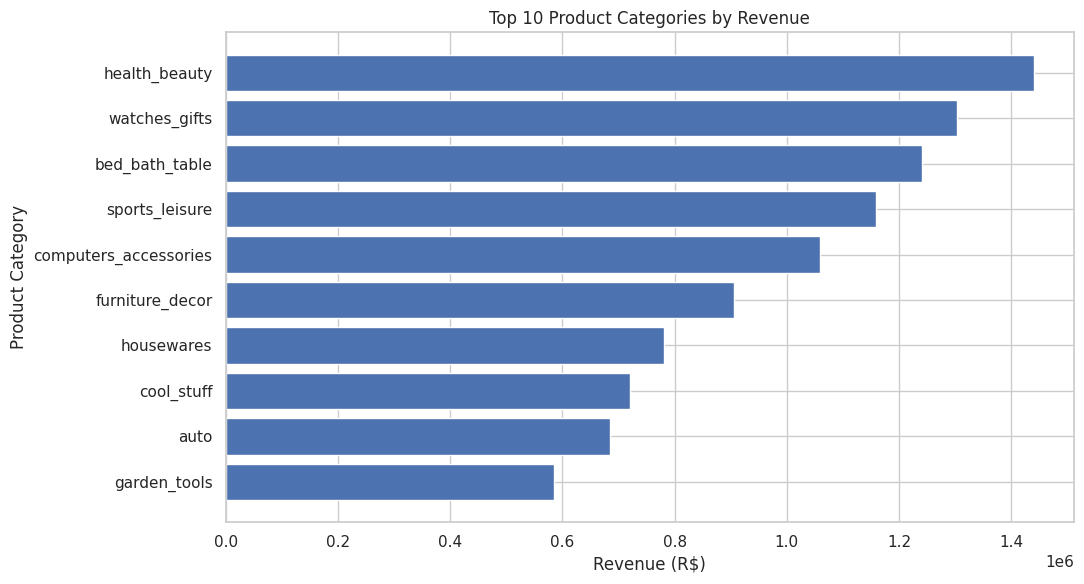

In [44]:
# Category-level performance.
category_performance = (
    analysis_df
    .dropna(subset=["product_category_name_english"])
    .groupby("product_category_name_english")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("payment_value", "sum"),
        average_order_value=("payment_value", "mean"),
        average_review_score=("review_score", "mean"),
        average_freight=("freight_value", "mean")
    )
    .sort_values("revenue", ascending=False)
)

print("Top categories by revenue:")
display(category_performance.head(15).round(2))

print("Top categories by order volume:")
display(
    category_performance
    .sort_values("orders", ascending=False)
    .head(15)
    .round(2)
)

# Categories with enough observations are more reliable for satisfaction comparison.
category_satisfaction = (
    category_performance[category_performance["orders"] >= 100]
    .sort_values("average_review_score")
)

print("Lowest-rated categories with at least 100 orders:")
display(category_satisfaction.head(10).round(2))

plt.figure(figsize=(11, 6))
top_categories = (
    category_performance
    .sort_values("revenue", ascending=False)
    .head(10)
    .sort_values("revenue")
)
plt.barh(top_categories.index, top_categories["revenue"])
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue (R$)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

## **14. Question 5 — Payment Behavior**

,orders,revenue,average_order_value,average_installments,average_review_score
payment_type,,,,,
credit_card,76504,12735995.96,166.47,3.51,4.09
boleto,19784,2869361.27,145.03,1.00,4.09
debit_card,1528,218092.61,142.73,1.00,4.17
voucher,1621,185422.28,114.39,1.00,3.95
not_defined,3,0.00,0.00,1.00,1.67


,orders,average_order_value,average_review_score
payment_installments,,,
0.0,2,94.32,5.00
1.0,48268,121.04,4.12
2.0,12363,129.12,4.11
3.0,10429,144.36,4.06
4.0,7070,165.06,4.05
5.0,5227,184.89,4.06
6.0,3908,211.59,4.08
7.0,1622,189.34,4.04
8.0,4251,309.77,4.02


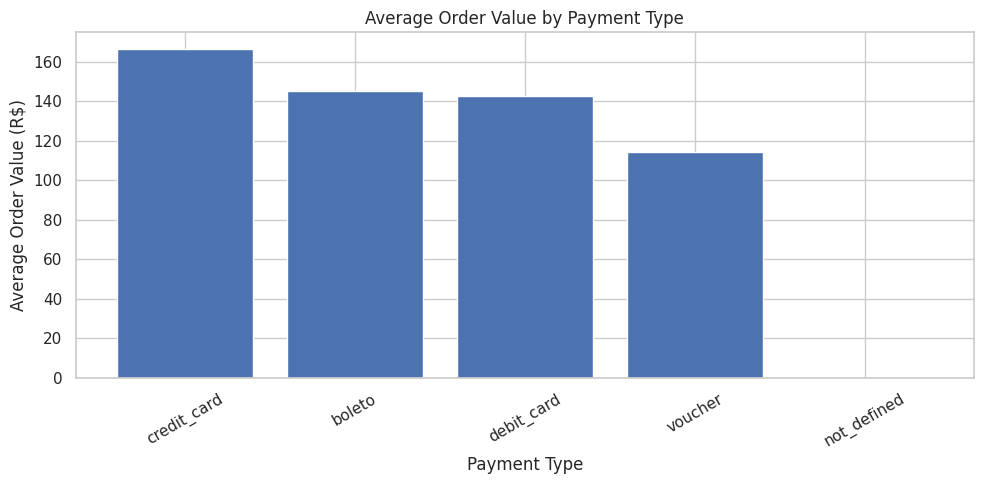

,payment_installments,payment_value,review_score
payment_installments,1.000,0.319,-0.031
payment_value,0.319,1.000,-0.049
review_score,-0.031,-0.049,1.000


In [45]:
# Payment method performance.
payment_performance = (
    analysis_df
    .dropna(subset=["payment_type"])
    .groupby("payment_type")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("payment_value", "sum"),
        average_order_value=("payment_value", "mean"),
        average_installments=("payment_installments", "mean"),
        average_review_score=("review_score", "mean")
    )
    .sort_values("revenue", ascending=False)
)

display(payment_performance.round(2))

# Installment-level analysis.
installment_performance = (
    analysis_df
    .dropna(subset=["payment_installments"])
    .groupby("payment_installments")
    .agg(
        orders=("order_id", "nunique"),
        average_order_value=("payment_value", "mean"),
        average_review_score=("review_score", "mean")
    )
    .sort_index()
)

display(installment_performance.round(2))

plt.figure(figsize=(10, 5))
plt.bar(
    payment_performance.index,
    payment_performance["average_order_value"]
)
plt.title("Average Order Value by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Order Value (R$)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Correlation is descriptive only; it does not establish causation.
payment_corr = (
    analysis_df[
        ["payment_installments", "payment_value", "review_score"]
    ]
    .corr()
)

display(payment_corr.round(3))

## **15. Question 6 — Root Cause Analysis**

,orders,average_review_score,average_delivery_delay,average_delivery_time,on_time_rate,average_freight,average_order_value,average_items
low_review,,,,,,,,
0,84992,4.58,-12.16,11.44,94.77,22.07,133.75,1.12
1,14449,1.22,-4.43,20.22,56.09,27.42,162.25,1.29


Factors ranked by absolute correlation with review score:


,correlation
on_time_delivery,0.446
delivery_time_days,-0.334
delivery_delay_days,-0.267
order_item_count,-0.116
freight_value,-0.089
payment_value,-0.049
order_value,-0.040
payment_installments,-0.031


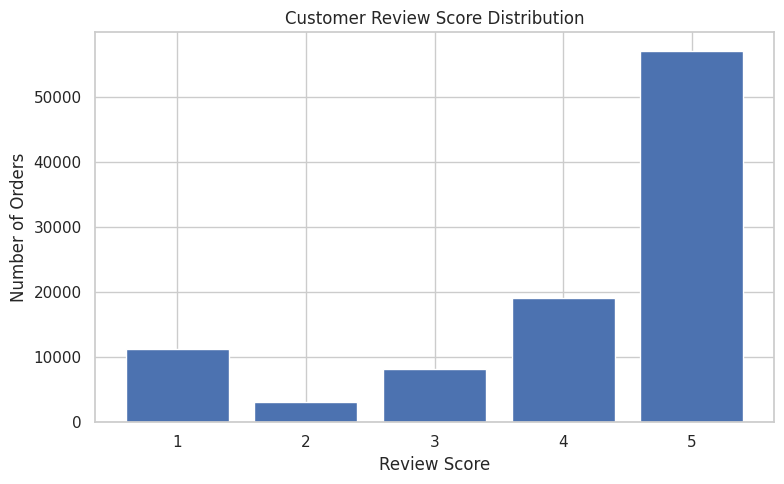

In [46]:
# Focus on orders with a valid customer review.
root_cause_df = analysis_df[
    [
        "review_score",
        "delivery_delay_days",
        "delivery_time_days",
        "on_time_delivery",
        "freight_value",
        "order_value",
        "order_item_count",
        "payment_value",
        "payment_installments"
    ]
].copy()

# Define low reviews as scores of 1 or 2.
root_cause_df["low_review"] = np.where(
    root_cause_df["review_score"] <= 2,
    1,
    0
)

# Compare operational metrics for low-review and higher-review orders.
root_cause_summary = (
    root_cause_df
    .groupby("low_review")
    .agg(
        orders=("review_score", "size"),
        average_review_score=("review_score", "mean"),
        average_delivery_delay=("delivery_delay_days", "mean"),
        average_delivery_time=("delivery_time_days", "mean"),
        on_time_rate=("on_time_delivery", "mean"),
        average_freight=("freight_value", "mean"),
        average_order_value=("order_value", "mean"),
        average_items=("order_item_count", "mean")
    )
)

root_cause_summary["on_time_rate"] *= 100
display(root_cause_summary.round(2))

# Rank numeric factors by absolute correlation with review score.
numeric_factors = [
    "delivery_delay_days",
    "delivery_time_days",
    "on_time_delivery",
    "freight_value",
    "order_value",
    "order_item_count",
    "payment_value",
    "payment_installments"
]

factor_correlations = (
    analysis_df[numeric_factors + ["review_score"]]
    .corr()["review_score"]
    .drop("review_score")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Factors ranked by absolute correlation with review score:")
display(factor_correlations.to_frame("correlation").round(3))

# Review score distribution.
plt.figure(figsize=(8, 5))
plt.hist(
    analysis_df["review_score"].dropna(),
    bins=np.arange(0.5, 5.6, 1),
    rwidth=0.8
)
plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

## **16. Key Findings**

In [47]:
# Generate a concise evidence-based findings summary.
# This cell is self-contained and does not depend on Section 13 variables.

total_orders = analysis_df["order_id"].nunique()
total_revenue = analysis_df["payment_value"].sum()
avg_review = analysis_df["review_score"].mean()

on_time_rate = analysis_df["on_time_delivery"].mean() * 100
late_review = analysis_df.loc[
    analysis_df["delivery_delay_days"] > 0, "review_score"
].mean()
on_time_review = analysis_df.loc[
    analysis_df["delivery_delay_days"] <= 0, "review_score"
].mean()

# Category performance is calculated locally so this section can run independently.
category_summary = (
    analysis_df
    .dropna(subset=["product_category_name_english"])
    .groupby("product_category_name_english")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("payment_value", "sum"),
        average_review_score=("review_score", "mean")
    )
    .sort_values("revenue", ascending=False)
)

top_category = category_summary.index[0] if not category_summary.empty else "N/A"

# Customer-state summary is also calculated locally.
state_summary = (
    analysis_df
    .dropna(subset=["customer_state"])
    .groupby("customer_state")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("payment_value", "sum"),
        average_review_score=("review_score", "mean")
    )
    .sort_values("orders", ascending=False)
)

top_customer_state = state_summary.index[0] if not state_summary.empty else "N/A"

# Use a minimum order threshold to avoid over-interpreting tiny categories.
category_satisfaction = category_summary[
    category_summary["orders"] >= 100
].sort_values("average_review_score")

if not category_satisfaction.empty:
    lowest_rated_category = category_satisfaction.index[0]
    lowest_rated_category_score = category_satisfaction.loc[
        lowest_rated_category, "average_review_score"
    ]
else:
    lowest_rated_category = "N/A"
    lowest_rated_category_score = np.nan

print("KEY FINDINGS")
print("-" * 60)
print(f"1. Total orders analyzed: {total_orders:,.0f}")
print(f"2. Total payment value recorded: R$ {total_revenue:,.2f}")
print(f"3. Average customer review score: {avg_review:.2f}/5")
print(f"4. On-time delivery rate: {on_time_rate:.2f}%")
print(f"5. Average review score for on-time/early orders: {on_time_review:.2f}")
print(f"6. Average review score for late orders: {late_review:.2f}")
print(f"7. Highest-revenue product category: {top_category}")
print(f"8. Highest-order-volume customer state: {top_customer_state}")

if lowest_rated_category != "N/A":
    print(
        f"9. Lowest-rated category among categories with at least 100 orders: "
        f"{lowest_rated_category} ({lowest_rated_category_score:.2f}/5)"
    )

print(
    "\nInterpretation: these are observational associations. "
    "They should not be interpreted as proof of causation."
)


KEY FINDINGS
------------------------------------------------------------
1. Total orders analyzed: 99,441
2. Total payment value recorded: R$ 16,008,872.12
3. Average customer review score: 4.09/5
4. On-time delivery rate: 89.15%
5. Average review score for on-time/early orders: 4.29
6. Average review score for late orders: 2.57
7. Highest-revenue product category: health_beauty
8. Highest-order-volume customer state: SP
9. Lowest-rated category among categories with at least 100 orders: office_furniture (3.62/5)

Interpretation: these are observational associations. They should not be interpreted as proof of causation.


## **17. Business Recommendations**

* Prioritize late-delivery reduction: monitor orders approaching their estimated delivery date and intervene before they become late.

* Use delivery performance as a customer-experience KPI: segment reviews by delivery-delay group and investigate categories or regions with unusually poor results.

* Focus operational improvements on high-volume/high-revenue categories and regions first, because improvements there can affect a larger share of marketplace activity.

* Monitor freight costs by seller and destination state. High freight costs combined with weak review scores should be investigated for possible logistics or customer-experience issues.

* Maintain payment flexibility while monitoring order value and customer-experience metrics across payment methods and installment levels.

* Build a recurring marketplace dashboard containing order volume, revenue, average review score, on-time delivery rate, delivery delay, freight value, and category performance.

## **18. Conclusion**

The Olist dataset provides a detailed view of marketplace activity across orders, payments, products, sellers, customers, delivery performance, and reviews. The analysis combines these sources into an order-level analytical dataset and evaluates marketplace growth, delivery performance, geographic and seller patterns, category performance, payment behavior, and factors associated with customer satisfaction.

The strongest analytical emphasis is on the relationship between delivery performance and customer reviews. Late delivery, delivery duration, freight cost, product category, geography, and payment characteristics can be compared to identify operational areas that deserve attention. Because this is observational data, the results describe associations rather than definitive causal relationships.

The completed analysis therefore supports a practical marketplace-management approach: monitor performance over time, identify high-impact operational bottlenecks, prioritize high-volume areas for improvement, and continuously track customer satisfaction alongside logistics and commercial KPIs.